In [59]:
import numpy as np

"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
# TODO: Create the matrix described above
# Hint: Use np.ones and array slicing

arr = np.ones((5,5))
arr[1:4,1:4] =0

print(arr)


# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1


normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)



# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
# TODO: Calculate theta_hat using the normal equation
# TODO: Print the estimated coefficients and compare with true_theta 

XT_X_inv = np.linalg.inv(X.T @ X)
theta_hat = XT_X_inv @ X.T @ y

print(f"True Theta:      {true_theta}")
print(f"Estimated Theta: {theta_hat.round(4)}")




[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
True Theta:      [ 2.5 -1.2  3.7]
Estimated Theta: [ 2.5172 -1.1978  3.724 ]


In [63]:
import pandas as pd
import numpy as np

"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""


# Create sample dataset
np.random.seed(42)
n_students = 200

data = { 
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)



# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset
# TODO: Identify and count missing values
# TODO: Fill missing exam_score with the mean score for the student's major
# TODO: Fill missing hours_studied with the median for the student's year

df.info()
df_missing = df.isnull().sum()
print(df_missing)

df['exam_score'] = df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))

# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
# TODO: Find the major with the highest average exam_score
# TODO: Calculate the correlation between hours_studied and exam_score
# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)

major_means = df.groupby('major')['exam_score'].mean()
print(major_means)

highest_major = major_means.idxmax()
highest_score = major_means.max()

correlation = df['hours_studied'].corr(df['exam_score'])

conditions = [
    df['exam_score'] > 90,
    (df['exam_score'] >= 80) & (df['exam_score'] <= 90),
    (df['exam_score'] >= 70) & (df['exam_score'] < 80)
]
choices = ['Excellent', 'Good', 'Average']

df['performance'] = np.select(conditions, choices, default='Needs Improvement')

print(df[['major', 'exam_score', 'performance']].head()) #go over

# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)


multi_group = df.groupby(['major', 'year']).agg(
    student_count=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)

print(multi_group)

top_5 = df.nlargest(5, 'exam_score')

print(top_5[['student_id', 'major', 'year', 'exam_score']].to_string(index=False))


pivot_table = df.pivot_table(
    values='exam_score', 
    index='major', 
    columns='year', 
    aggfunc='mean'
)

print(pivot_table)




<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 9.5 KB
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
     major  exam_score        performance
0  Physics   68.199753  Needs Improvement
1  Biology   77.322537            Average
2  

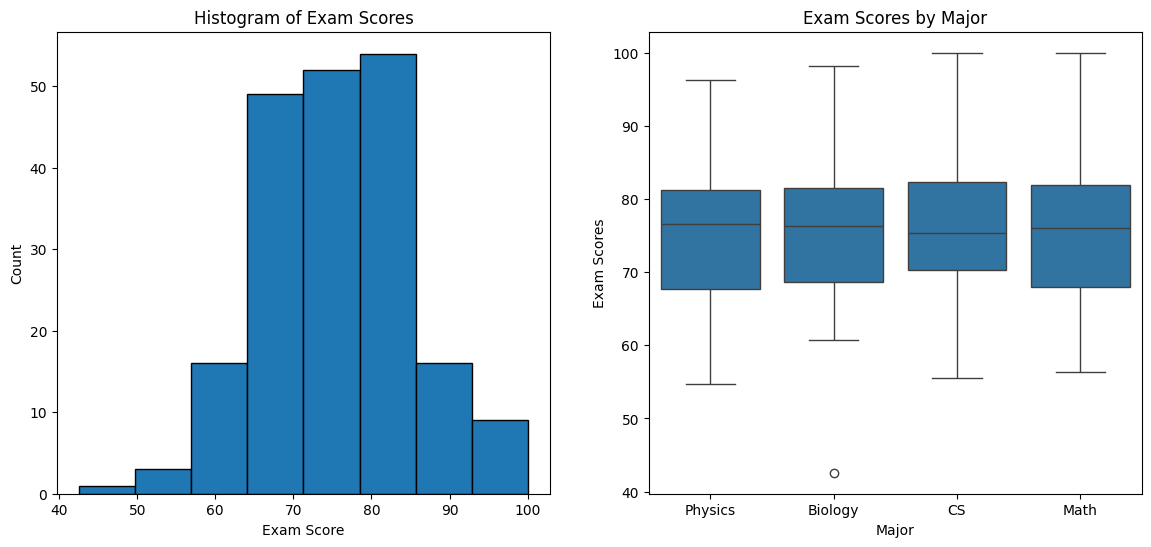

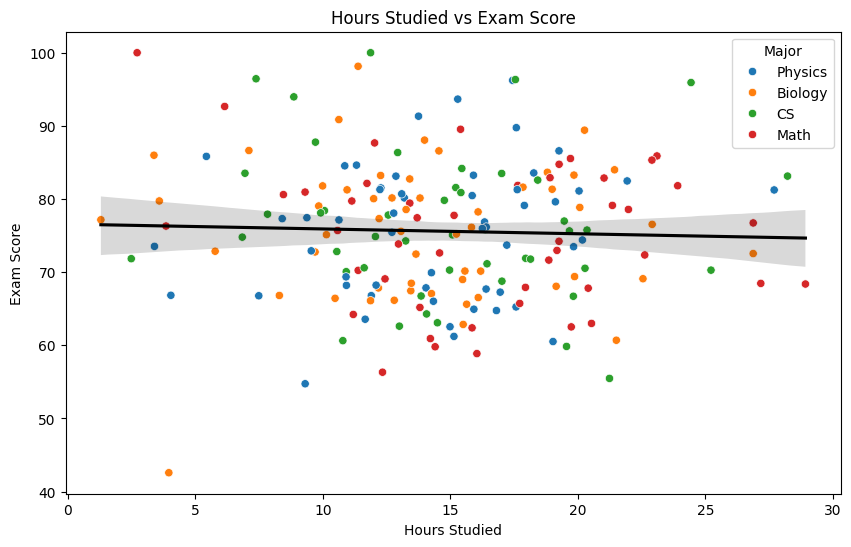

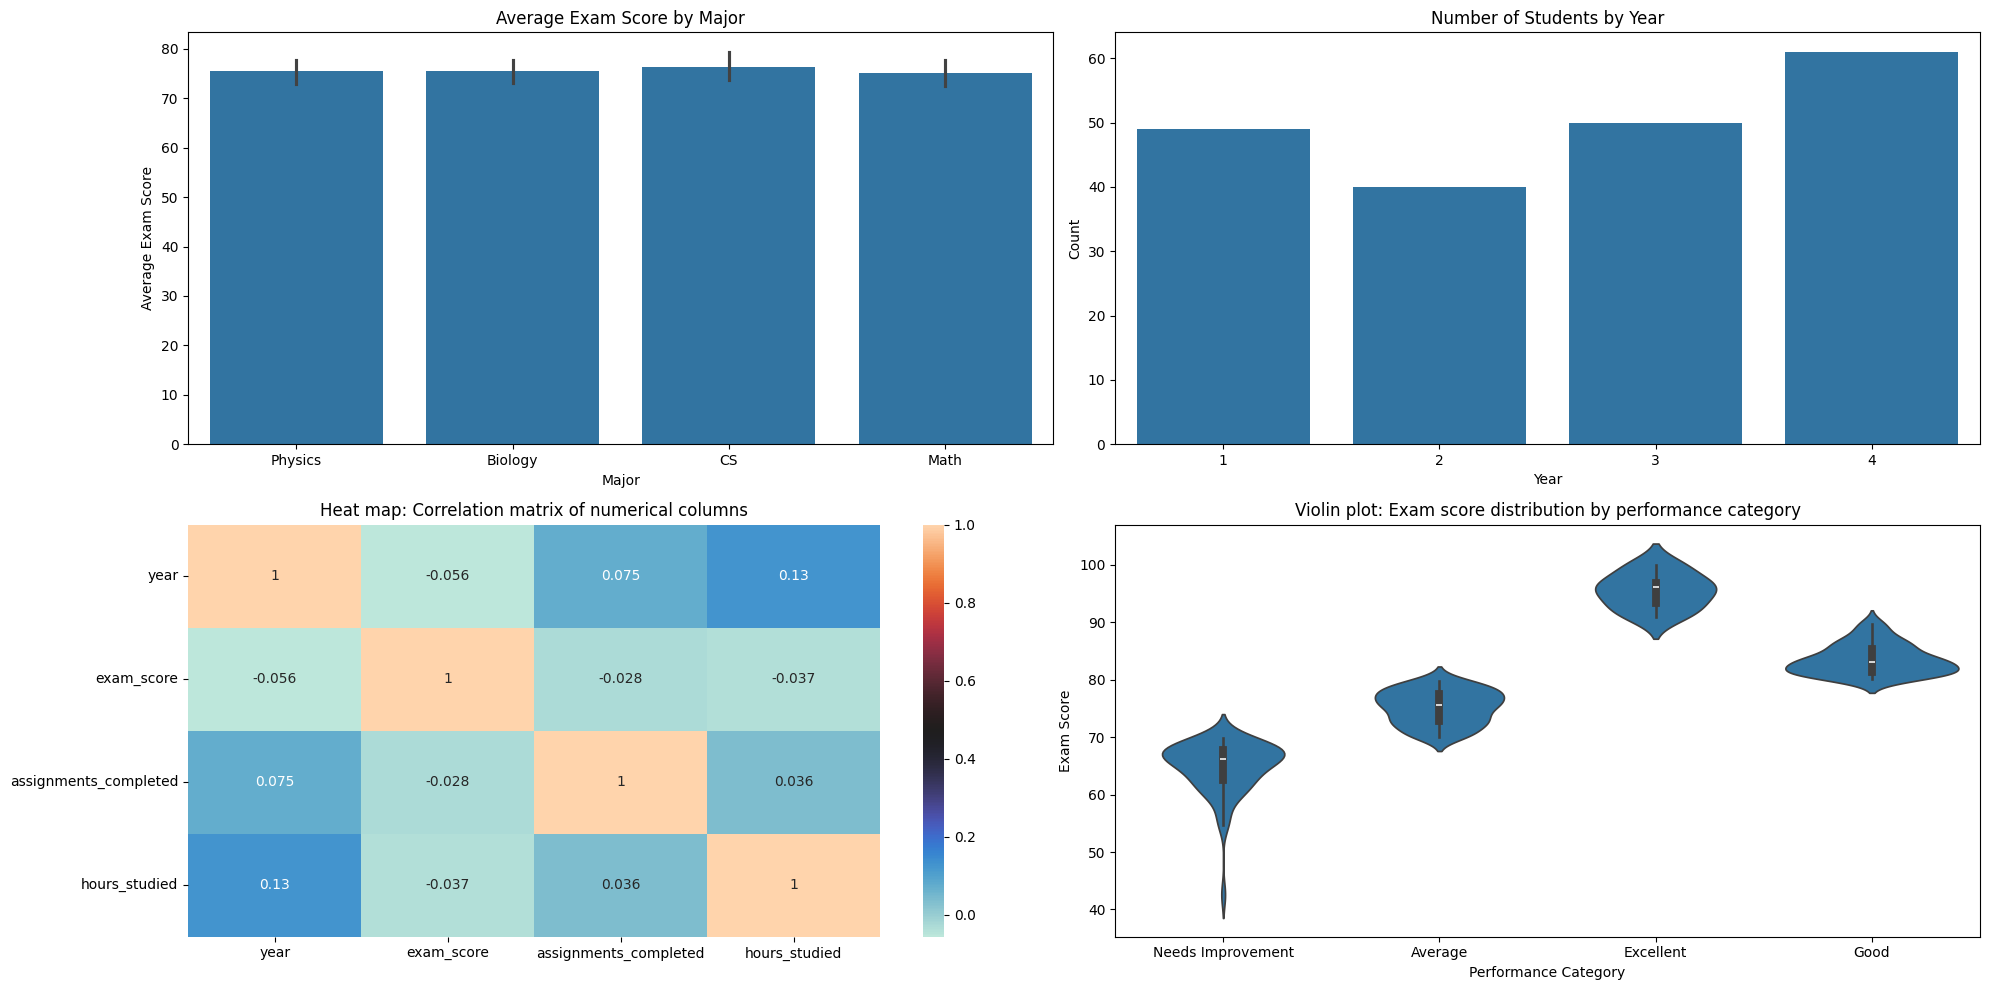

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

# Continue using the df from Exercise 5

np.random.seed(42) 
n_students = 200 

data = { 
    'student_id': range(1000, 1000 + n_students), 
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students), 
    'year': np.random.choice([1, 2, 3, 4], n_students), 
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100), 
    'assignments_completed': np.random.randint(0, 11, n_students), 
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40) 
} 

df = pd.DataFrame(data) 

# Conditions for performance mapping
conditions = [ 
    df['exam_score'] > 90, 
    (df['exam_score'] >= 80) & (df['exam_score'] <= 90), 
    (df['exam_score'] >= 70) & (df['exam_score'] < 80) 
] 
choices = ['Excellent', 'Good', 'Average'] 

# CHANGED: Fixed the column name to 'performance_category' to match Exercise 6 requirements
df['performance_category'] = np.select(conditions, choices, default='Needs Improvement')


# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
# TODO: Add appropriate titles, labels, and styling


fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))



axes1[0].hist(df['exam_score'], bins=8, edgecolor='black')
axes1[0].set_xlabel('Exam Score')
axes1[0].set_ylabel('Count')
axes1[0].set_title('Histogram of Exam Scores')

sns.boxplot(data=df, x='major', y='exam_score', ax=axes1[1])
axes1[1].set_xlabel('Major')
axes1[1].set_ylabel('Exam Scores')
axes1[1].set_title('Exam Scores by Major')



# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='major')


sns.regplot(data=df, x='hours_studied', y='exam_score', scatter=False, color='black')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')
plt.legend(title='Major')
plt.show()


# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability


fig, axes = plt.subplots(2, 2, figsize=(20, 10))


sns.barplot(data=df, x='major', y='exam_score', ax=axes[0, 0])
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Exam Score')
axes[0, 0].set_title('Average Exam Score by Major')


sns.countplot(data=df, x='year', ax=axes[0, 1])
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Number of Students by Year')


numeric_df = df[['year', 'exam_score', 'assignments_completed', 'hours_studied']]
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='icefire', ax=axes[1, 0])
axes[1, 0].set_title('Heat map: Correlation matrix of numerical columns')


sns.violinplot(data=df, x='performance_category', y='exam_score', ax=axes[1, 1])
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')
axes[1, 1].set_title('Violin plot: Exam score distribution by performance category')

plt.tight_layout()
plt.show()

age_group  customer_count  average_income  average_CLV  total_CLV
    18-25              81        50634.02       718.37   58188.06
    26-35              73        48747.15       747.74   54584.92
    36-50             160        48516.90       732.80  117247.46
    51-70             186        50713.16       762.69  141860.99
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6     38  58876.388563                  10          110.331527    0.166667   
9     40  48809.492879                  10          110.228581    0.166667   
19    41  21282.756976                   8          119.651218    0.333333   
24    38  53981.193911                   8          120.320786    0.333333   
57    64  45956.146951                   7          135.470585    0.416667   
60    25  66508.326980                   7          142.042870    0.416667   
76    61  62482.396341                   7          127.841352    0.416667   
79    53  32054.912570                  10    

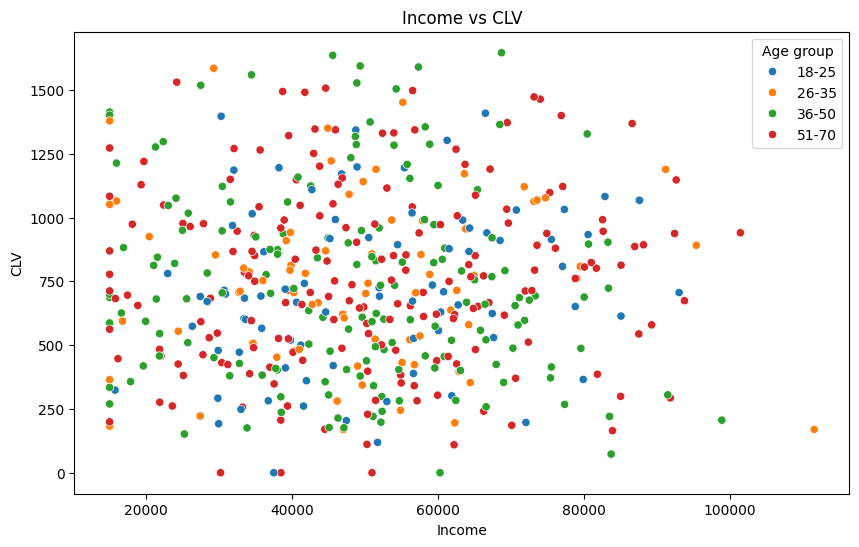

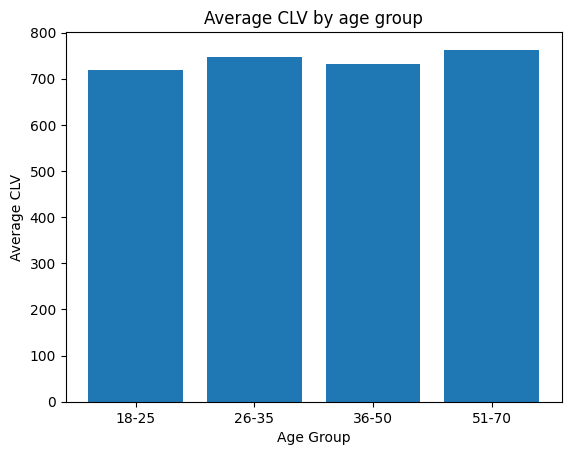

<Axes: >

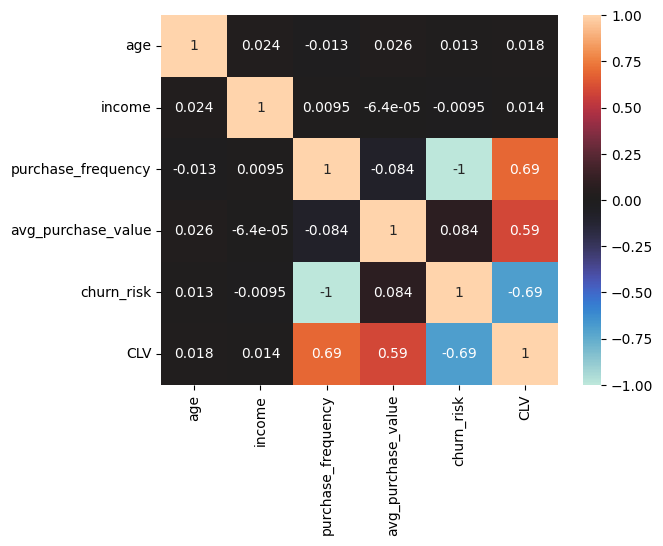

In [67]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)

max_freq = customers['purchase_frequency'].max()
customers['churn_risk'] = 1-(customers['purchase_frequency']/max_freq)
customers['CLV'] = customers['purchase_frequency'] * avg_purchase_value * (1 + customers['churn_risk'])


# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70

age_bins = [17, 25, 35, 50, 70]
age_labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=age_bins, labels=age_labels)


# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV

age_segment_summary = customers.groupby('age_group', observed=False).agg(
    customer_count=('age', 'count'),
    average_income=('income', 'mean'),
    average_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).reset_index()


print(age_segment_summary.round(2).to_string(index=False))

# TODO: Identify top 10% of customers by CLV

clv_threshold = customers['CLV'].quantile(0.90)
top_10_percent_customers = customers[customers['CLV'] >= clv_threshold]

print(top_10_percent_customers)

# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap

plt.figure(figsize=(10, 6))

sns.scatterplot(data=customers, x='income', y='CLV', hue='age_group')



plt.xlabel('Income')
plt.ylabel('CLV')
plt.title('Income vs CLV')
plt.legend(title='Age group')
plt.show()




plt.bar(
    age_segment_summary['age_group'], 
    age_segment_summary['average_CLV'],

)

plt.xlabel('Age Group')
plt.ylabel('Average CLV')
plt.title('Average CLV by age group')
plt.show()


correlation = customers.corr(numeric_only = True)
sns.heatmap(correlation, annot=True, cmap='icefire')


# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations



CLV and purchase frequenncy has a high correlation. Income and average purchasing value has a low correlatin. A perfect negative correlation exist between purchase frquency and churn risk. This shows that as transaction rates drops, the likelihood the customer will stop getting the services of the company increases.